# import Section

In [1]:
import yfinance as yf
import lightgbm as lgb
from sklearn.metrics import classification_report
from sklearn.preprocessing import RobustScaler

# importing data , cleaning and preproccesing 

In [2]:

ticker = "AAPL"
start_date = "2023-01-01"
end_date = "2025-01-01"
stockbf24 = yf.download(ticker, start=start_date, end=end_date)
stockaf24 = yf.download("AAPL","2025-01-02","2026-05-10")

stockbf24['Tomorrow_Close'] = stockbf24['Close'].shift(-1)
close_bf = stockbf24['Close'].squeeze()
tomorrow_close_bf = stockbf24['Tomorrow_Close'].squeeze()
stockbf24['Close_direction'] = (tomorrow_close_bf > close_bf).astype(int)
stockbf24 = stockbf24.dropna()

stockaf24['Tomorrow_Close'] = stockaf24['Close'].shift(-1)
close_af = stockaf24['Close'].squeeze()
tomorrow_close_af = stockaf24['Tomorrow_Close'].squeeze()
stockaf24['Close_direction'] = (tomorrow_close_af > close_af).astype(int)
stockaf24 = stockaf24.dropna()

y_train = stockbf24['Close_direction']
X_train = stockbf24.drop(columns=['Close_direction', 'Tomorrow_Close'])

y_test = stockaf24['Close_direction']
X_test = stockaf24.drop(columns=['Close_direction', 'Tomorrow_Close'])

scalar = RobustScaler()

X_train_scaled = scalar.fit_transform(X_train)

X_test_scaled = scalar.transform(X_test)


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


# training the model

In [3]:
down_to_up_ratio = (y_train == 0).sum() / (y_train == 1).sum()
model = lgb.LGBMClassifier(objective='binary',
    class_weight= 'balanced',
    scale_pos_weight=down_to_up_ratio, 
    learning_rate=0.05,
    num_leaves=7,
    min_child_samples=10,
    random_state=42)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

print(classification_report(y_true=y_test, y_pred=y_pred))

[LightGBM] [Info] Number of positive: 282, number of negative: 219
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000089 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 835
[LightGBM] [Info] Number of data points in the train set: 501, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
              precision    recall  f1-score   support

           0       0.49      0.34      0.40       161
           1       0.53      0.68      0.60       176

    accuracy                           0.52       337
   macro avg       0.51      0.51      0.50       337
weighted avg       0.51      0.52      0.50       337



c:\Users\punee\miniconda3\envs\ml_env\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


# feature importance graph

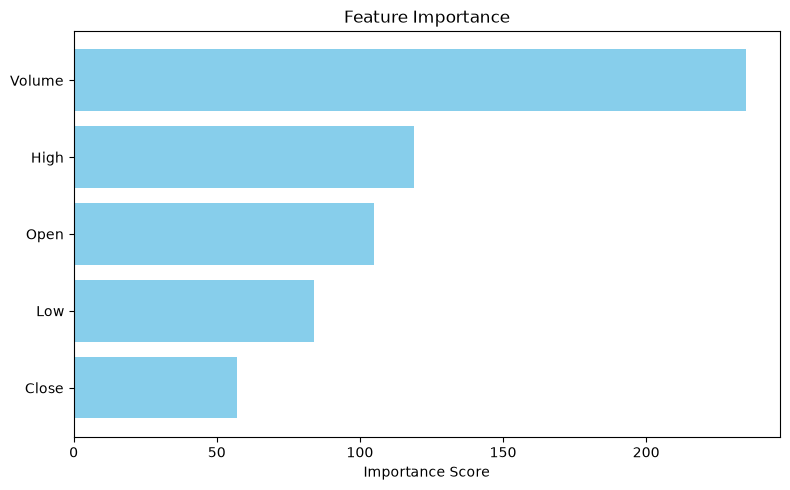

In [4]:
import matplotlib.pyplot as plt
import pandas as pd

clean_features = []
for col in X_train.columns:
    if isinstance(col, tuple):
        clean_features.append(col[0]) 
    else:
        clean_features.append(col)

importance = model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': clean_features,
    'Importance': importance
}).sort_values(by='Importance', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.xlabel('Importance Score')
plt.title('Feature Importance')
plt.tight_layout()
plt.show()